# 🌍 India Air Quality Index (AQI) Analysis & Prediction (2015–2023)

## 📌 Project Overview
Air pollution is one of the most critical environmental challenges in India. 
This project analyzes daily AQI data across major Indian cities and builds a machine learning model to predict AQI levels.

## 🎯 Objectives
- Perform comprehensive exploratory data analysis
- Identify key pollutants influencing AQI
- Build and evaluate regression models
- Interpret model results

## 📊 Dataset
- Time Period: 2015–2023
- Cities: 10 Major Indian Cities
- Observations: ~32,870 daily records
- Features: PM2.5, PM10, NO2, SO2, CO, O3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
df=pd.read_csv('/kaggle/input/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv')
df.head()

,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory


## 🔍 Data Understanding

In this section, we explore:
- Dataset size
- Data types
- Missing values
- Basic statistics


In [3]:
print('Shape:',df.shape)

Shape: (32870, 10)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB


In [5]:
df.describe()

,pm25,pm10,no2,so2,co,o3,aqi
count,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000
mean,80.757235,130.764579,40.165472,11.998476,0.802118,49.979732,88.122665
std,39.063392,43.937066,14.849411,4.882239,0.298156,14.912687,31.895407
min,5.000000,10.000000,5.000000,2.000000,0.100000,10.000000,11.000000
25%,53.154180,99.980177,29.990183,8.570939,0.599976,39.892800,65.000000
50%,80.336105,130.023453,40.141525,11.977979,0.800137,49.977582,88.000000
75%,107.496909,160.634804,50.190860,15.315028,1.003899,60.025440,110.000000
max,248.081036,330.014171,97.446733,34.395421,1.929870,118.431721,221.000000


In [6]:
df.isnull().sum()

city            0
date            0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
aqi             0
aqi_category    0
dtype: int64

In [7]:
df['date']=pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day

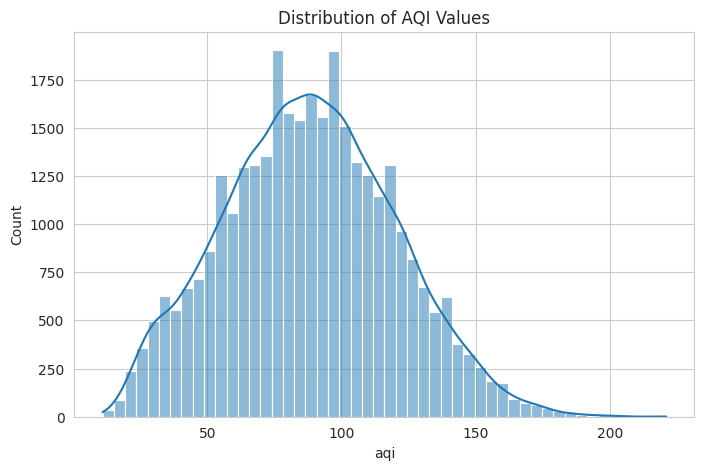

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['aqi'],bins=50,kde=True)
plt.title('Distribution of AQI Values')
plt.show()

🔎 Observation:
- AQI is right-skewed.
- Majority values fall in Moderate to Poor range.


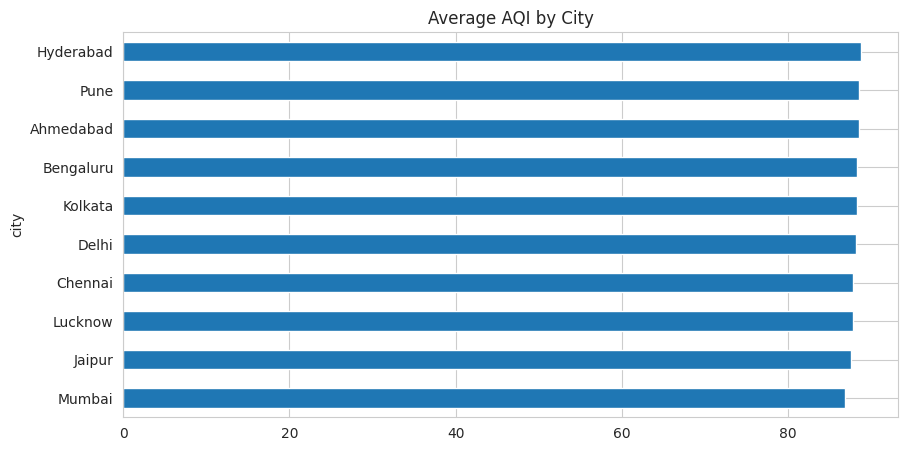

In [9]:
plt.figure(figsize=(10,5))
df.groupby('city')['aqi'].mean().sort_values().plot(kind='barh')
plt.title("Average AQI by City")
plt.show()

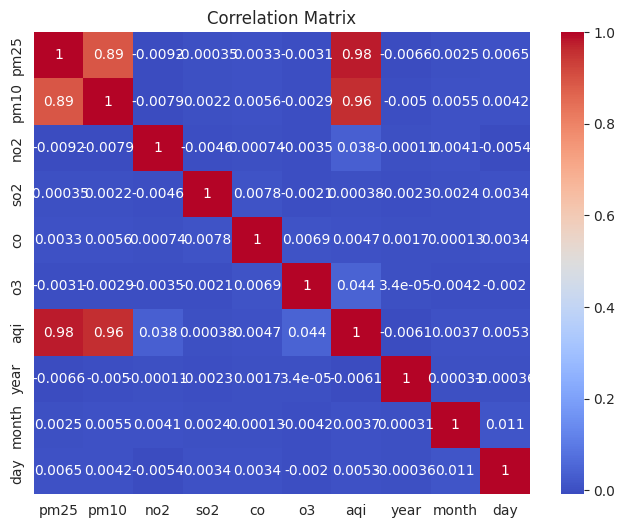

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True,),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

🔎 Key Insight:
- PM2.5 and PM10 show strongest correlation with AQI.
- Gaseous pollutants have moderate influence.


In [11]:
features=['pm25','pm10','no2','so2','co','o3']
x=df[features]
y=df['aqi']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [12]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

In [13]:
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

In [14]:
def evaluate(model_name,y_true,y_pred):
    return [
        model_name,
        r2_score(y_true,y_pred),
        mean_absolute_error(y_true,y_pred),
        np.sqrt(mean_squared_error(y_true,y_pred))
    ]

results=pd.DataFrame([
    evaluate('Linear Regression',y_test,lr_pred),
    evaluate('Random Forest',y_test,rf_pred),
],columns=['Model','R2 Score','MAE','RMSE'])

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.999918,0.249326,0.288050
1,Random Forest,0.999217,0.643359,0.892514


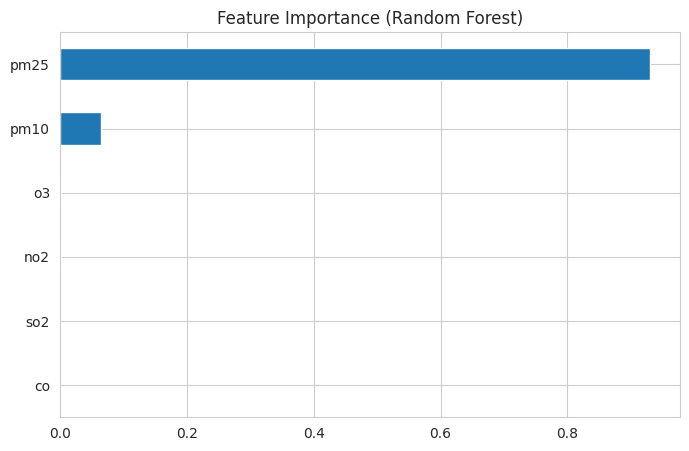

In [15]:
importance=pd.Series(rf.feature_importances_,index=features)
plt.figure(figsize=(8,5))
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.show()

# 🏁 Conclusion

- PM25 is the most significant contributor to AQI.
- Random Forest outperforms Linear Regression.
- The dataset demonstrates strong multivariate relationships.

## 📌 Future Improvements
- Add Time-Series Forecasting (ARIMA / LSTM)
- Add Meteorological Data (Temperature, Humidity)
- Use XGBoost for improved performance
- Deploy as AQI prediction web app
